Saved: /Users/nandan/Desktop/CTCs/IBM/dyn3_shotcost_tradeoff.png
Saved: /Users/nandan/Desktop/CTCs/IBM/dyn3_shotcost_tradeoff.pdf


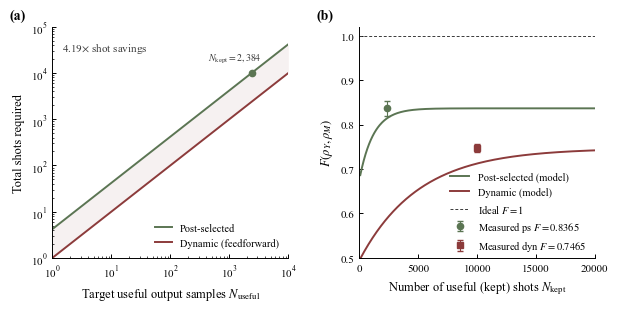

In [14]:
"""
Figure: Shot-cost & fidelity-vs-shot-cost tradeoff
Post-selected vs Dynamic (feedforward) on ibm_torino.

PRL-style: single panel pair (two-column width), Times serif, inward ticks,
muted sage / brick palette consistent with the rest of the paper.
"""
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Data ----------------
with open("dynamic_circuit_results.json") as f:
    d = json.load(f)

F_ps      = d["postselected"]["fidelity"]            # 0.8365
F_ps_ci   = d["postselected"]["fidelity_ci"]         # [0.8195, 0.8537]
n_kept_ps = d["postselected"]["n_kept"]              # 2384
n_tot_ps  = d["postselected"]["n_total"]             # 10000
p_succ    = n_kept_ps / n_tot_ps                     # 0.2384

F_dyn     = d["dynamic"]["fidelity"]                 # 0.7465
F_dyn_ci  = d["dynamic"]["fidelity_ci"]              # [0.7379, 0.7551]
n_kept_dyn = d["dynamic"]["n_kept"]                  # 10000

ratio     = d["tradeoff"]["shot_cost_ratio"]         # 4.19

# ---------------- PRL rcParams ----------------
mpl.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset":    "stix",
    "font.size":           8,
    "axes.labelsize":      9,
    "axes.titlesize":      9,
    "xtick.labelsize":     8,
    "ytick.labelsize":     8,
    "legend.fontsize":     7.5,
    "axes.linewidth":      0.7,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "xtick.minor.width":   0.5,
    "ytick.minor.width":   0.5,
    "xtick.major.size":    3.0,
    "ytick.major.size":    3.0,
    "xtick.minor.size":    1.6,
    "ytick.minor.size":    1.6,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.top":           False,
    "ytick.right":         False,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "savefig.bbox":        "tight",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
})

# Consistent paper palette
C_PS  = "#5b7553"   # sage  — post-selected
C_DYN = "#8c3b3b"   # brick — dynamic (feedforward)
C_GREY = "#3a3a3a"

# ---------------- Figure ----------------
# Two-column width ≈ 7.0 in; keep modest height
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(7.0, 3.0), gridspec_kw={"wspace": 0.30}
)

# ============ LEFT: shot-cost curves ============
N_useful = np.logspace(0, 4, 400)
shots_ps  = N_useful / p_succ        # post-selected: need 1/p_succ raw shots per useful
shots_dyn = N_useful                  # dynamic: every shot is kept

axL.loglog(N_useful, shots_ps,  color=C_PS,  lw=1.4, label="Post-selected")
axL.loglog(N_useful, shots_dyn, color=C_DYN, lw=1.4, label="Dynamic (feedforward)")

# Shade the savings region between the two
axL.fill_between(N_useful, shots_dyn, shots_ps,
                 color=C_DYN, alpha=0.07, linewidth=0)

# Marker for the actual measured operating point
axL.plot([n_kept_ps], [n_tot_ps], marker="o", ms=4.5,
         mfc=C_PS, mec=C_PS, zorder=5)

axL.annotate(
    f"$N_{{\\mathrm{{kept}}}} = {n_kept_ps:,}$",
    xy=(n_kept_ps, n_tot_ps), xytext=(-12, 6),
    textcoords="offset points",
    ha="center", va="bottom",
    fontsize=7, color=C_GREY,
)

# Savings annotation
axL.text(
    0.04, 0.94,
    f"{ratio:.2f}$\\times$ shot savings",
    transform=axL.transAxes, ha="left", va="top",
    fontsize=8, color=C_GREY,
)

axL.set_xlabel(r"Target useful output samples $N_{\mathrm{useful}}$")
axL.set_ylabel(r"Total shots required")
axL.set_xlim(1, 1e4)
axL.set_ylim(1, 1e5)
axL.legend(loc="lower right", frameon=False, handlelength=1.6)

# Panel label
axL.text(-0.18, 1.02, "(a)", transform=axL.transAxes,
         fontsize=10, fontweight="bold", va="bottom")

# ============ RIGHT: fidelity-vs-shot-cost (illustrative model) ============
# Same model as the original draft: F(N) approaches its asymptotic measured value
# from below via an exponential. Anchored so F(N -> inf) = measured F, with
# characteristic scale tau = n_kept/2 (matches original).
N_arr = np.linspace(100, 20000, 400)
F_ps_curve  = F_ps  - (1 - F_ps)  * np.exp(-N_arr / (n_kept_ps  / 2))
F_dyn_curve = F_dyn - (1 - F_dyn) * np.exp(-N_arr / (n_kept_dyn / 2))
F_ps_curve  = np.clip(F_ps_curve,  0, 1)
F_dyn_curve = np.clip(F_dyn_curve, 0, 1)

axR.plot(N_arr, F_ps_curve,  color=C_PS,  lw=1.4, label="Post-selected (model)")
axR.plot(N_arr, F_dyn_curve, color=C_DYN, lw=1.4, label="Dynamic (model)")
axR.axhline(1.0, color=C_GREY, lw=0.7, linestyle=(0,(3,2)), label=r"Ideal $F = 1$")

# Measured points with 95% CI error bars
axR.errorbar(
    n_kept_ps, F_ps,
    yerr=[[F_ps - F_ps_ci[0]], [F_ps_ci[1] - F_ps]],
    fmt="o", color=C_PS, ms=4.5, capsize=2.5, lw=0.8, elinewidth=0.8,
    zorder=5, label=f"Measured ps $F = {F_ps:.4f}$",
)
axR.errorbar(
    n_kept_dyn, F_dyn,
    yerr=[[F_dyn - F_dyn_ci[0]], [F_dyn_ci[1] - F_dyn]],
    fmt="s", color=C_DYN, ms=4.0, capsize=2.5, lw=0.8, elinewidth=0.8,
    zorder=5, label=f"Measured dyn $F = {F_dyn:.4f}$",
)

axR.set_xlabel(r"Number of useful (kept) shots $N_{\mathrm{kept}}$")
axR.set_ylabel(r"$F(\rho_Y,\rho_M)$")
axR.set_xlim(0, 20000)
axR.set_ylim(0.5, 1.02)
axR.legend(loc="lower right", bbox_to_anchor=(1.0, -0.02),
           frameon=False, handlelength=1.8)

axR.text(-0.18, 1.02, "(b)", transform=axR.transAxes,
         fontsize=10, fontweight="bold", va="bottom")

# ---------------- Save ----------------
out_png = "/Users/nandan/Desktop/CTCs/IBM/dyn3_shotcost_tradeoff.png"
out_pdf = "/Users/nandan/Desktop/CTCs/IBM/dyn3_shotcost_tradeoff.pdf"
plt.savefig(out_png, dpi=600)
plt.savefig(out_pdf)
print("Saved:", out_png)
print("Saved:", out_pdf)